In [18]:
# Data Preparation and Processing

import pandas as pd

file_path = r'I:\GEO DATA ANALYSIS\Telecom_Accra_Optimization\data\raw\620.csv'

# Preview
print("First 5 raw lines of the file:")
with open(file_path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 5:
            break
        print(line.strip())

# Load the data
df = pd.read_csv(file_path, header=None, low_memory=False)

print("\nDataset shape (rows, columns):", df.shape)

# Preview first few rows
print("\nFirst 5 rows (raw):")
print(df.head())

# Assign standard OpenCelliD column names
columns = [
    'radio',      # e.g. GSM, UMTS, LTE
    'mcc',        # 620 for Ghana
    'net',        # MNC (network code)
    'area',       # LAC/TAC
    'cell',       # Cell ID
    'unit',       # PSC/PCI (often NaN)
    'lon',
    'lat',
    'range',      # estimated range in meters
    'samples',
    'changeable',
    'created',
    'updated',
    'averageSignal'
]

# Check if column count matches
if len(df.columns) == len(columns):
    df.columns = columns
    print("\nColumns assigned successfully.")
else:
    print(f"\nWarning: File has {len(df.columns)} columns, expected {len(columns)}")
    print("Actual columns:", list(df.columns))

# Basic summary
print("\nData types:")
print(df.dtypes)

print("\nCoordinate ranges (should be Ghana: lon ~ -2.5 to 1.2, lat ~4.7 to 11):")
print(df[['lon', 'lat']].describe())

print("\nNumber of unique cell identifiers:")
print(df[['mcc', 'net', 'area', 'cell']].drop_duplicates().shape[0])

# Rough filter for Greater Accra area (bounding box)
accra_df = df[
    (df['lat'].between(5.4, 6.2)) & 
    (df['lon'].between(-0.5, 0.4))
]

print(f"\nApproximate towers in/near Greater Accra: {len(accra_df)}")
if not accra_df.empty:
    print("\nSample of Accra-area towers:")
    print(accra_df.head(8))
else:
    print("No towers found in approximate Accra bounds — check coordinates or expand box.")

First 5 raw lines of the file:
GSM,620,2,30,13095,0,-0.439,5.7923,10752,4,1,1445070045,1740811328,0
GSM,620,2,29,23081,0,-0.2658,6.0607,1000,4,1,1438660207,1757585043,0
GSM,620,2,30,33126,0,-0.6082,5.8055,3008,3,1,1445163953,1736923325,0
GSM,620,2,30,23166,0,-0.365,5.9152,15976,6,1,1458964465,1736836827,0
GSM,620,2,30,23167,0,-0.3886,5.9156,16970,6,1,1458964465,1736836825,0

Dataset shape (rows, columns): (16623, 14)

First 5 rows (raw):
    0    1   2   3      4   5       6       7      8   9   10          11  \
0  GSM  620   2  30  13095   0 -0.4390  5.7923  10752   4   1  1445070045   
1  GSM  620   2  29  23081   0 -0.2658  6.0607   1000   4   1  1438660207   
2  GSM  620   2  30  33126   0 -0.6082  5.8055   3008   3   1  1445163953   
3  GSM  620   2  30  23166   0 -0.3650  5.9152  15976   6   1  1458964465   
4  GSM  620   2  30  23167   0 -0.3886  5.9156  16970   6   1  1458964465   

           12  13  
0  1740811328   0  
1  1757585043   0  
2  1736923325   0  
3  1736836827  

In [19]:
print("Unique radio technologies in the dataset:")
print(df['radio'].unique())

print("\nCount of each radio type:")
print(df['radio'].value_counts())

print("\nPercentage breakdown:")
print(df['radio'].value_counts(normalize=True) * 100)

# View data
print("\nSample rows with non-GSM radio (up to 10):")
print(df[df['radio'] != 'GSM'].head(10))

Unique radio technologies in the dataset:
<StringArray>
['GSM', 'UMTS', 'LTE']
Length: 3, dtype: str

Count of each radio type:
radio
LTE     11391
UMTS     4841
GSM       391
Name: count, dtype: int64

Percentage breakdown:
radio
LTE     68.525537
UMTS    29.122300
GSM      2.352163
Name: proportion, dtype: float64

Sample rows with non-GSM radio (up to 10):
    radio  mcc  net   area       cell  unit     lon     lat  range  samples  \
23   UMTS  620    2      3  209726741   460 -1.5859  6.7786   3617       10   
24   UMTS  620    2      3  209756741   460 -1.6120  6.7605   1000        3   
33    LTE  620    2  10120      86273     0 -0.2263  5.6103   5258       14   
42    LTE  620    2  10220      75011     0 -0.1744  5.6308   1238       15   
43    LTE  620    2  10220     122881     0 -0.1790  5.6228   1000        2   
44   UMTS  620    2      2  235944422     0 -0.3045  5.7064   4075        4   
46   UMTS  620    2      2  235983278     0 -0.3090  5.7260   1000        2   
79    

CRS: EPSG:4326
Bounds: BoundingBox(left=-3.255416639, bottom=4.738750182, right=1.1920833430000002, top=11.172916823)
Resolution: (0.000833333329960652, 0.0008333333300090661)
NoData value: -99999.0


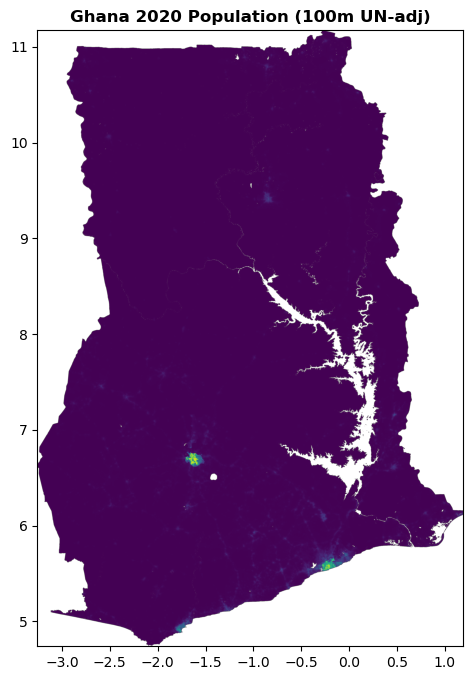

In [20]:
# Load population
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

pop_file = r'I:\GEO DATA ANALYSIS\Telecom_Accra_Optimization\data\raw\gha_ppp_2020_UNadj.tif'

with rasterio.open(pop_file) as src:
    print("CRS:", src.crs)             
    print("Bounds:", src.bounds)
    print("Resolution:", src.res)
    print("NoData value:", src.nodata)

    # Plot full Ghana
    fig, ax = plt.subplots(figsize=(10, 8))
    show(src, ax=ax, cmap='viridis', title='Ghana 2020 Population (100m UN-adj)')
    plt.show()

In [21]:
import numpy as np

with rasterio.open(pop_file) as src:
    pop_data = src.read(1)  # band 1 = population counts
    pop_valid = pop_data[pop_data != src.nodata]  # exclude NoData

    print("Total estimated population (sum):", np.sum(pop_valid))
    print("Max people per pixel:", np.max(pop_valid))
    print("Mean people per pixel (valid):", np.mean(pop_valid))
    print("Number of valid pixels:", len(pop_valid))

Total estimated population (sum): 3.1072944e+07
Max people per pixel: 226.34395
Mean people per pixel (valid): 1.1310999
Number of valid pixels: 27471439


Columns in the shapefile:
['adm1_name', 'adm1_name1', 'adm1_name2', 'adm1_name3', 'adm1_pcode', 'adm0_name', 'adm0_name1', 'adm0_name2', 'adm0_name3', 'adm0_pcode', 'valid_on', 'valid_to', 'area_sqkm', 'cod_versio', 'lang', 'lang1', 'lang2', 'lang3', 'adm1_ref_n', 'center_lat', 'center_lon', 'geometry']

Unique region names:

Found 'Greater Accra' in column 'adm1_name'

Found 'Greater Accra' in column 'adm1_ref_n'

Greater Accra Region extracted successfully!
       adm1_name adm1_name1 adm1_name2 adm1_name3 adm1_pcode adm0_name  \
6  Greater Accra       None       None       None       GH07     Ghana   

  adm0_name1 adm0_name2 adm0_name3 adm0_pcode  ...    area_sqkm cod_versio  \
6       None       None       None         GH  ...  3699.325231       V_01   

   lang lang1 lang2 lang3     adm1_ref_n center_lat center_lon  \
6    en  None  None  None  Greater Accra   5.789886   0.247324   

                                            geometry  
6  POLYGON ((0.25909 6.09808, 0.26208 6.09

I:\Temporary\ipykernel_14372\3641566445.py:44: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
I:\Temporary\ipykernel_14372\3641566445.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


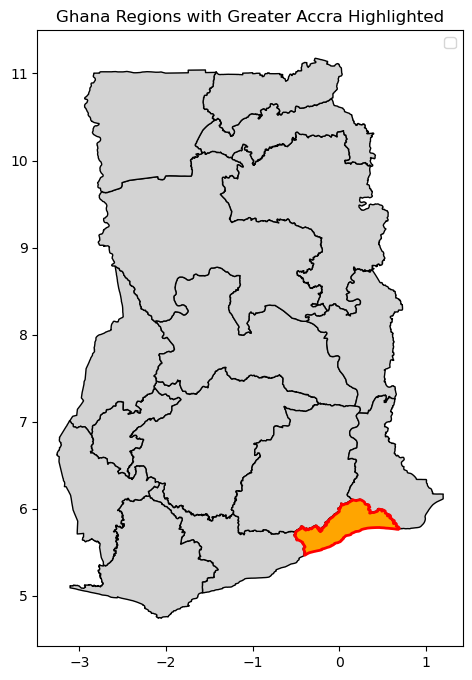

In [22]:
import geopandas as gpd
import matplotlib.pyplot as plt


admin1_path = r'I:\GEO DATA ANALYSIS\Telecom_Accra_Optimization\data\raw\gha_admin1.shp'

# Load the regions
gdf_regions = gpd.read_file(admin1_path)

# Print available columns
print("Columns in the shapefile:")
print(gdf_regions.columns.tolist())

# Show unique region names
print("\nUnique region names:")
for col in ['ADM1_EN', 'admin1Name', 'NAME_1', 'region', 'ADM1_PCODE', 'Shape_Name']:
    if col in gdf_regions.columns:
        print(f"\nFrom column '{col}':")
        print(gdf_regions[col].unique())
        print("Number of regions:", len(gdf_regions[col].unique()))


greater_accra_col = None
for col in gdf_regions.columns:
    if gdf_regions[col].astype(str).str.contains('Greater Accra', case=False).any():
        greater_accra_col = col
        print(f"\nFound 'Greater Accra' in column '{col}'")

if greater_accra_col:
    gdf_accra = gdf_regions[gdf_regions[greater_accra_col].str.contains('Greater Accra', case=False)]
    print("\nGreater Accra Region extracted successfully!")
    print(gdf_accra.head())
    print("CRS:", gdf_accra.crs)
else:
    print("\n'Greater Accra' not found — show all unique names from possible columns and check spelling.")
    print(gdf_regions.head())

# Visualize
fig, ax = plt.subplots(figsize=(8, 8))
gdf_regions.plot(ax=ax, edgecolor='black', facecolor='lightgray')
if 'gdf_accra' in locals():
    gdf_accra.plot(ax=ax, edgecolor='red', facecolor='orange', linewidth=2, label='Greater Accra')
ax.set_title('Ghana Regions with Greater Accra Highlighted')
plt.legend()
plt.show()

In [23]:
# Save Greater Accra boundary as a new shapefile
output_boundary_path = r'I:\GEO DATA ANALYSIS\Telecom_Accra_Optimization\data\processed\greater_accra_boundary.shp'
gdf_accra.to_file(output_boundary_path)

print(f"Greater Accra boundary saved to: {output_boundary_path}")

Greater Accra boundary saved to: I:\GEO DATA ANALYSIS\Telecom_Accra_Optimization\data\processed\greater_accra_boundary.shp


In [24]:
import geopandas as gpd
import pandas as pd
import os

processed_dir = r'I:\GEO DATA ANALYSIS\Telecom_Accra_Optimization\data\processed'
os.makedirs(processed_dir, exist_ok=True)

# Load full towers as GeoDataFrame
towers_path = r'I:\GEO DATA ANALYSIS\Telecom_Accra_Optimization\data\processed\ghana_towers_clean.csv'
df_towers = pd.read_csv(towers_path, low_memory=False)

gdf_towers = gpd.GeoDataFrame(
    df_towers,
    geometry=gpd.points_from_xy(df_towers.lon, df_towers.lat),
    crs="EPSG:4326"
)

# Load Greater Accra boundary
boundary_path = r'I:\GEO DATA ANALYSIS\Telecom_Accra_Optimization\data\processed\greater_accra_boundary.shp'
gdf_boundary = gpd.read_file(boundary_path)

# Clip towers to boundary
gdf_accra_exact = gpd.sjoin(
    gdf_towers,
    gdf_boundary,
    how="inner",          
    predicate="within"   
).drop(columns=['index_right']) 

# Convert back to regular DataFrame
accra_towers_exact = gdf_accra_exact.drop(columns='geometry')

# Save
accra_exact_path = os.path.join(processed_dir, 'accra_towers_boundary.csv')
accra_towers_exact.to_csv(accra_exact_path, index=False)

print(f"Saved precise Greater Accra towers (boundary-clipped): {accra_exact_path}")
print(f"Number of towers inside Greater Accra Region: {len(accra_towers_exact)}")
print(f"(Compared to rough box: previously ~5246)")

Saved precise Greater Accra towers (boundary-clipped): I:\GEO DATA ANALYSIS\Telecom_Accra_Optimization\data\processed\accra_towers_boundary.csv
Number of towers inside Greater Accra Region: 4627
(Compared to rough box: previously ~5246)


In [25]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import os

# Paths
raw_pop_path     = r'I:\GEO DATA ANALYSIS\Telecom_Accra_Optimization\data\raw\gha_ppp_2020_UNadj.tif'
boundary_path    = r'I:\GEO DATA ANALYSIS\Telecom_Accra_Optimization\data\processed\greater_accra_boundary.shp'
processed_pop_path = r'I:\GEO DATA ANALYSIS\Telecom_Accra_Optimization\data\processed\greater_accra_population_2020.tif'


os.makedirs(os.path.dirname(processed_pop_path), exist_ok=True)

# Load boundary and prepare geometry
gdf_boundary = gpd.read_file(boundary_path)
gdf_boundary = gdf_boundary.to_crs(epsg=4326)  # ensure same CRS as raster
geoms = [feature["geometry"] for feature in gdf_boundary.__geo_interface__["features"]]

# Clip
with rasterio.open(raw_pop_path) as src:
    out_image, out_transform = mask(src, geoms, crop=True, nodata=src.nodata)
    
    out_meta = src.meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform
    })
    
    with rasterio.open(processed_pop_path, "w", **out_meta) as dest:
        dest.write(out_image)

print(f"Clipped population raster successfully saved to:\n{processed_pop_path}")


Clipped population raster successfully saved to:
I:\GEO DATA ANALYSIS\Telecom_Accra_Optimization\data\processed\greater_accra_population_2020.tif


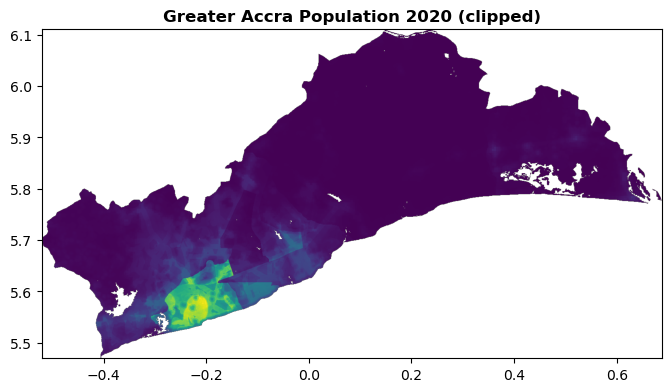

In [26]:
# Clip Greater Accra Raster
from rasterio.plot import show
import matplotlib.pyplot as plt

with rasterio.open(processed_pop_path) as src:
    fig, ax = plt.subplots(figsize=(8, 8))
    show(src, ax=ax, cmap='viridis', title='Greater Accra Population 2020 (clipped)')
    plt.show()

In [28]:
# Base Mapping & Network Coverage Analysis

import geopandas as gpd
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import contextily as ctx
import pandas as pd
import os

processed_dir = r'I:\GEO DATA ANALYSIS\Telecom_Accra_Optimization\data\processed'

# Load boundary
boundary_path = os.path.join(processed_dir, 'greater_accra_boundary.shp')
gdf_boundary = gpd.read_file(boundary_path)

# Load precise Accra towers
towers_path = os.path.join(processed_dir, 'accra_towers_boundary.csv')
df_towers = pd.read_csv(towers_path, low_memory=False)
gdf_towers = gpd.GeoDataFrame(
    df_towers,
    geometry=gpd.points_from_xy(df_towers.lon, df_towers.lat),
    crs="EPSG:4326"
)

# Color by radio type
radio_colors = {'LTE': '#2ca02c', 'UMTS': '#1f77b4', 'GSM': '#d62728'}
gdf_towers['color'] = gdf_towers['radio'].map(radio_colors).fillna('gray')

# Load clipped population raster
pop_path = os.path.join(processed_dir, 'greater_accra_population_2020.tif')

print(f"Loaded {len(gdf_towers)} towers")
print("Boundary CRS:", gdf_boundary.crs)

Loaded 4627 towers
Boundary CRS: EPSG:4326


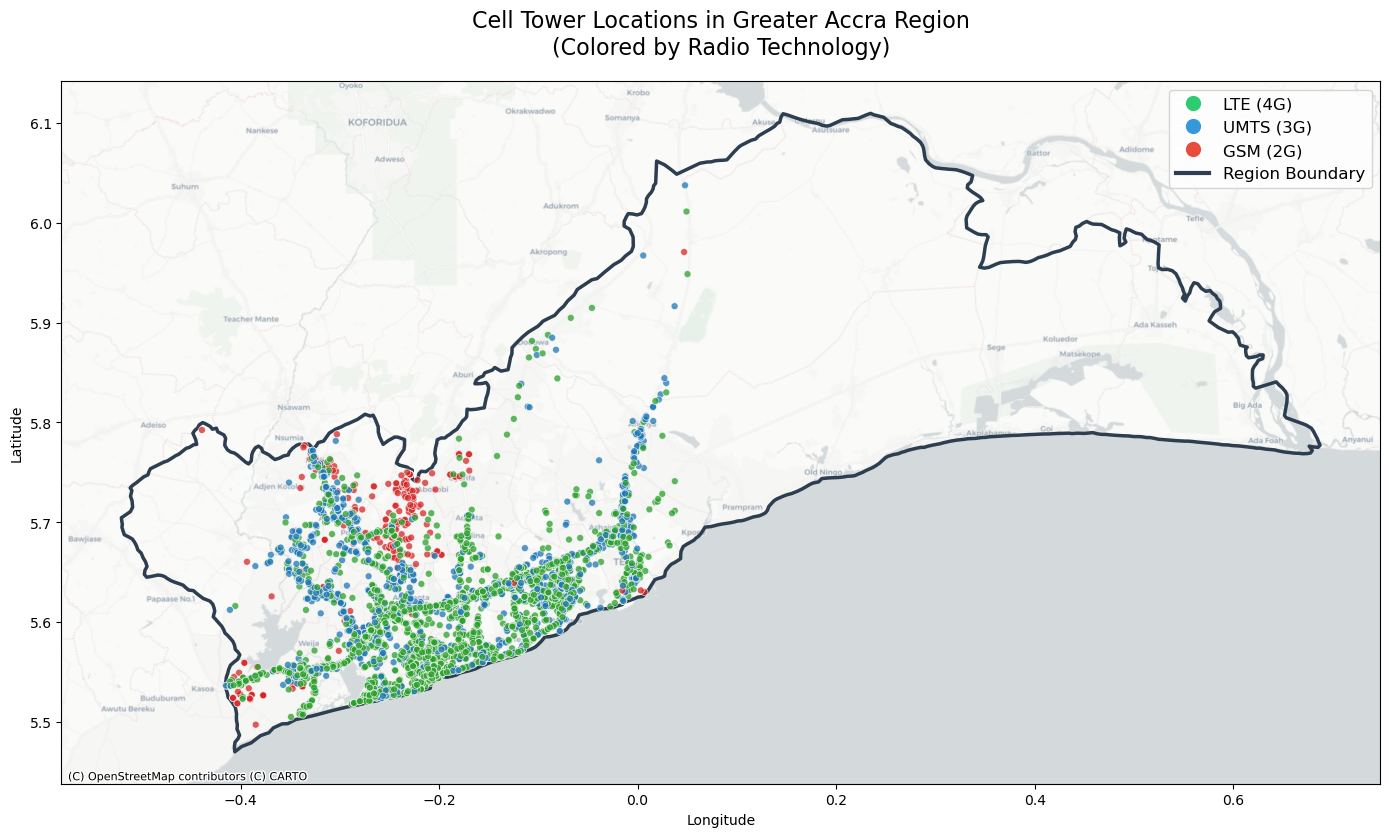

In [29]:
fig, ax = plt.subplots(figsize=(14, 12))

# Boundary outline
gdf_boundary.plot(ax=ax, color='none', edgecolor='#2c3e50', linewidth=2.5, label='Greater Accra')

# Towers by technology
gdf_towers.plot(ax=ax, color=gdf_towers['color'], markersize=25, alpha=0.75, edgecolor='white', linewidth=0.5)

# Basemap
ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.CartoDB.Positron, zoom=11)

ax.set_title("Cell Tower Locations in Greater Accra Region\n(Colored by Radio Technology)", fontsize=16, pad=20)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='LTE (4G)', markerfacecolor='#2ecc71', markersize=12, markeredgecolor='white'),
    Line2D([0], [0], marker='o', color='w', label='UMTS (3G)', markerfacecolor='#3498db', markersize=12, markeredgecolor='white'),
    Line2D([0], [0], marker='o', color='w', label='GSM (2G)', markerfacecolor='#e74c3c', markersize=12, markeredgecolor='white'),
    Line2D([0], [0], color='#2c3e50', lw=3, label='Region Boundary')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12, frameon=True)

plt.tight_layout()
plt.show()

In [30]:
print("Tower count by radio technology in Greater Accra:")
print(gdf_towers['radio'].value_counts())

print("\nTowers by operator (MNC/net):")
print(gdf_towers['net'].value_counts())

Tower count by radio technology in Greater Accra:
radio
LTE     2690
UMTS    1648
GSM      289
Name: count, dtype: int64

Towers by operator (MNC/net):
net
2    2902
1    1717
3       8
Name: count, dtype: int64


In [48]:
# Imports

import geopandas as gpd
import numpy as np


# Ensure GeoDataFrame is valid
gdf_towers = gdf_towers.copy()
gdf_towers = gdf_towers.set_geometry('geometry')


#  Reproject to UTM (meters)
# Ghana - UTM Zone 30N (EPSG:32630)
gdf_towers_utm = gdf_towers.to_crs(epsg=32630)


#  FIXED BUFFER (2 km)
gdf_towers_utm['buffer_fixed'] = gdf_towers_utm.geometry.buffer(2000)


#  DYNAMIC BUFFER (based on 'range')
# Clean range values
ranges = gdf_towers_utm['range'].copy()

# Handle missing values
ranges = ranges.fillna(2000)

# Enforce realistic telecom limits
ranges = np.where((ranges < 100) | (ranges > 20000), 2000, ranges)

# Create buffers (vectorized)
gdf_towers_utm['buffer_dynamic'] = gdf_towers_utm.geometry.buffer(ranges)


# Convert buffers back to WGS84
#  Fixed buffer GeoDataFrame 
gdf_fixed = gdf_towers_utm[['buffer_fixed']].copy()
gdf_fixed = gdf_fixed.set_geometry('buffer_fixed')
gdf_fixed = gdf_fixed.to_crs(epsg=4326)

#  Dynamic buffer GeoDataFrame 
gdf_dynamic = gdf_towers_utm[['buffer_dynamic']].copy()
gdf_dynamic = gdf_dynamic.set_geometry('buffer_dynamic')
gdf_dynamic = gdf_dynamic.to_crs(epsg=4326)

#  Original towers back to WGS84 
gdf_towers = gdf_towers_utm.to_crs(epsg=4326)


#  Merge back into one dataset
gdf_towers['buffer_fixed'] = gdf_fixed.geometry
gdf_towers['buffer_dynamic'] = gdf_dynamic.geometry



print("Buffers created successfully (fixed + dynamic)")
print(gdf_towers.head())

Buffers created successfully (fixed + dynamic)
  radio  mcc  net  area   cell  unit     lon     lat  range  samples  ...  \
0   GSM  620    2    30  13095     0 -0.4390  5.7923  10752        4  ...   
1   GSM  620    2    62  24037     0 -0.2953  5.6011   1700        5  ...   
2   GSM  620    2    37  12565     0 -0.3848  5.4969   8450        5  ...   
3   GSM  620    2    55  34104    -1 -0.2996  5.7150   1480        9  ...   
4   GSM  620    2    55  14104    -1 -0.2849  5.7151   3442       21  ...   

   lang  lang1  lang2  lang3     adm1_ref_n  center_lat  center_lon  \
0    en    NaN    NaN    NaN  Greater Accra    5.789886    0.247324   
1    en    NaN    NaN    NaN  Greater Accra    5.789886    0.247324   
2    en    NaN    NaN    NaN  Greater Accra    5.789886    0.247324   
3    en    NaN    NaN    NaN  Greater Accra    5.789886    0.247324   
4    en    NaN    NaN    NaN  Greater Accra    5.789886    0.247324   

                 geometry                                      

Fixed 2 km union coverage area: 1433.6 km²
Dynamic (range-based) union coverage area: 2143.2 km²
Percentage of Greater Accra covered (fixed): 38.8%
Percentage of Greater Accra covered (dynamic): 57.9%


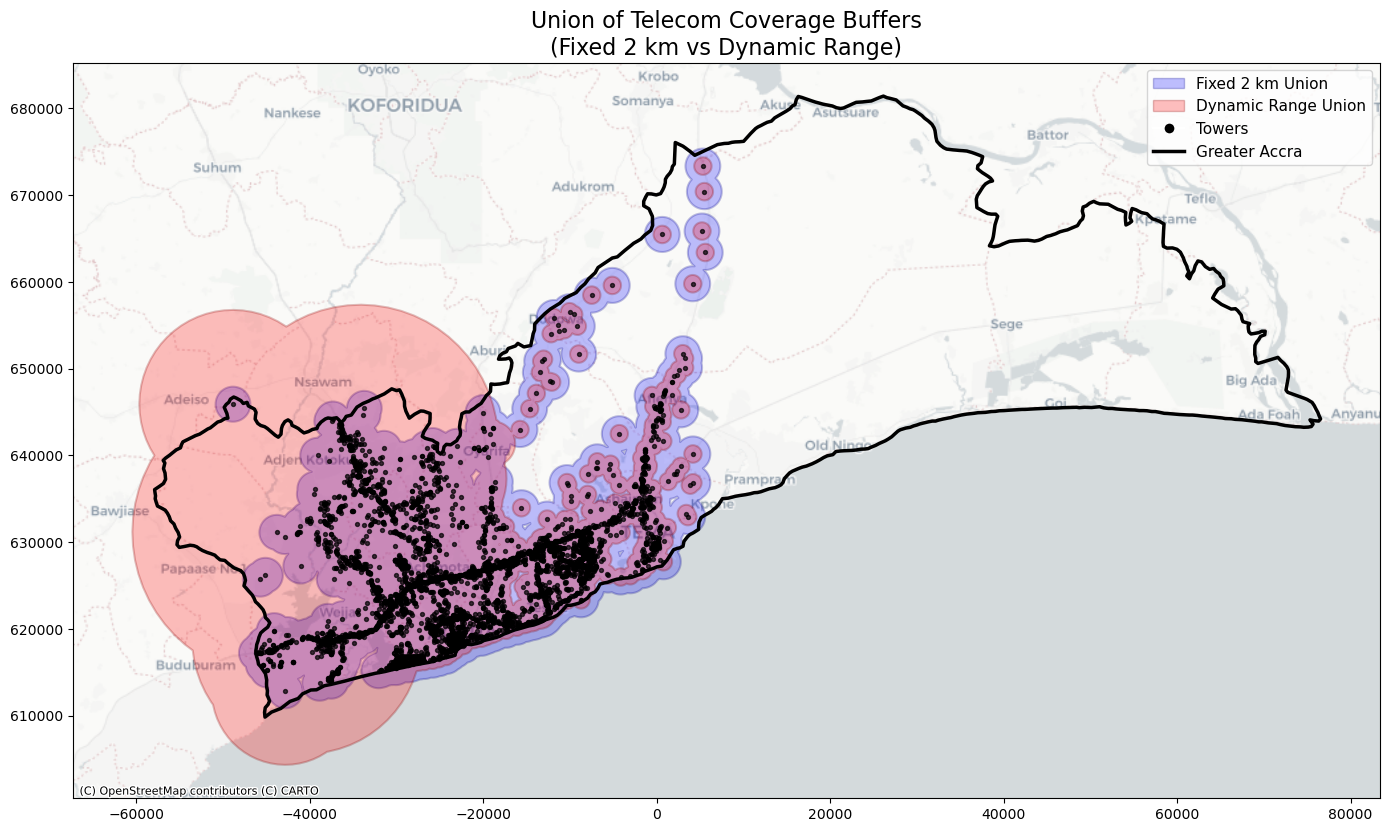

In [32]:
# Dissolve - Total Coverage Polygons

# Dissolve using GeoSeries directly 
coverage_fixed = gdf_towers['buffer_fixed'].union_all()
coverage_dynamic = gdf_towers['buffer_dynamic'].union_all()

# Convert back to GeoDataFrame for plotting
coverage_fixed_gdf = gpd.GeoDataFrame(geometry=[coverage_fixed], crs="EPSG:4326")
coverage_dynamic_gdf = gpd.GeoDataFrame(geometry=[coverage_dynamic], crs="EPSG:4326")



# Calculate Coverage Area (in km²) – accurate in UTM
# Reproject the GeoDataFrames 
coverage_fixed_utm = coverage_fixed_gdf.to_crs(epsg=32630)
coverage_dynamic_utm = coverage_dynamic_gdf.to_crs(epsg=32630)

# Area in square meters - km²
area_fixed_km2 = coverage_fixed_utm.geometry.area.sum() / 1_000_000
area_dynamic_km2 = coverage_dynamic_utm.geometry.area.sum() / 1_000_000

print(f"Fixed 2 km union coverage area: {area_fixed_km2:.1f} km²")
print(f"Dynamic (range-based) union coverage area: {area_dynamic_km2:.1f} km²")

# Greater Accra approximate area from earlier boundary metadata
region_area_km2 = 3699
print(f"Percentage of Greater Accra covered (fixed): {area_fixed_km2 / region_area_km2 * 100:.1f}%")
print(f"Percentage of Greater Accra covered (dynamic): {area_dynamic_km2 / region_area_km2 * 100:.1f}%")



# Visualization of Dissolved Coverage
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Convert everything to Web Mercator
coverage_fixed_web = coverage_fixed_gdf.to_crs(epsg=3857)
coverage_dynamic_web = coverage_dynamic_gdf.to_crs(epsg=3857)
gdf_towers_web = gdf_towers.to_crs(epsg=3857)
gdf_boundary_web = gdf_boundary.to_crs(epsg=3857)

# Plot
fig, ax = plt.subplots(figsize=(14, 12))

coverage_fixed_web.plot(
    ax=ax,
    facecolor='blue',
    edgecolor='darkblue',
    linewidth=1.5,
    alpha=0.25
)

coverage_dynamic_web.plot(
    ax=ax,
    facecolor='red',
    edgecolor='darkred',
    linewidth=1.5,
    alpha=0.25
)

gdf_towers_web.plot(ax=ax, color='black', markersize=8, alpha=0.7)
gdf_boundary_web.plot(ax=ax, color='none', edgecolor='black', linewidth=2.5)

# Basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# Legend
ax.legend(
    handles=[
        Patch(facecolor='blue', edgecolor='darkblue', alpha=0.25, label='Fixed 2 km Union'),
        Patch(facecolor='red', edgecolor='darkred', alpha=0.25, label='Dynamic Range Union'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=8, label='Towers'),
        plt.Line2D([0], [0], color='black', lw=2.5, label='Greater Accra')
    ],
    loc='upper right',
    fontsize=11
)

ax.set_title("Union of Telecom Coverage Buffers\n(Fixed 2 km vs Dynamic Range)", fontsize=16)

plt.tight_layout()
plt.show()

In [33]:
# Population-Weighted Coverage & Gap Identification

import rasterio
from rasterio.features import geometry_mask
import numpy as np

pop_path = r'I:\GEO DATA ANALYSIS\Telecom_Accra_Optimization\data\processed\greater_accra_population_2020.tif'

with rasterio.open(pop_path) as src:
    pop_raster = src.read(1)
    pop_transform = src.transform
    pop_nodata = src.nodata if src.nodata is not None else -99999

    # Mask for fixed coverage
    mask_fixed = geometry_mask(
        coverage_fixed_gdf.geometry.values,
        out_shape=src.shape,
        transform=pop_transform,
        invert=True  
    )

    # Mask for dynamic coverage
    mask_dynamic = geometry_mask(
        coverage_dynamic_gdf.geometry.values,
        out_shape=src.shape,
        transform=pop_transform,
        invert=True
    )

    # Valid population pixels
    valid_pop = pop_raster[pop_raster != pop_nodata]

    # Population covered
    pop_covered_fixed = pop_raster[mask_fixed & (pop_raster != pop_nodata)].sum()
    pop_covered_dynamic = pop_raster[mask_dynamic & (pop_raster != pop_nodata)].sum()
    pop_total = valid_pop.sum()

    print(f"Total population in Greater Accra (raster): {pop_total:,.0f}")
    print(f"Population covered by fixed 2 km buffers: {pop_covered_fixed:,.0f} ({pop_covered_fixed / pop_total * 100:.1f}%)")
    print(f"Population covered by dynamic range buffers: {pop_covered_dynamic:,.0f} ({pop_covered_dynamic / pop_total * 100:.1f}%)")
    print(f"Population potentially underserved (fixed): {pop_total - pop_covered_fixed:,.0f} ({(pop_total - pop_covered_fixed) / pop_total * 100:.1f}%)")
    print(f"Population potentially underserved (dynamic): {pop_total - pop_covered_dynamic:,.0f} ({(pop_total - pop_covered_dynamic) / pop_total * 100:.1f}%)")

Total population in Greater Accra (raster): 5,294,676
Population covered by fixed 2 km buffers: 4,838,642 (91.4%)
Population covered by dynamic range buffers: 4,730,160 (89.3%)
Population potentially underserved (fixed): 456,034 (8.6%)
Population potentially underserved (dynamic): 564,516 (10.7%)


Raw priority points: 27132
Saved priority locations: priority_tower_locations.geojson


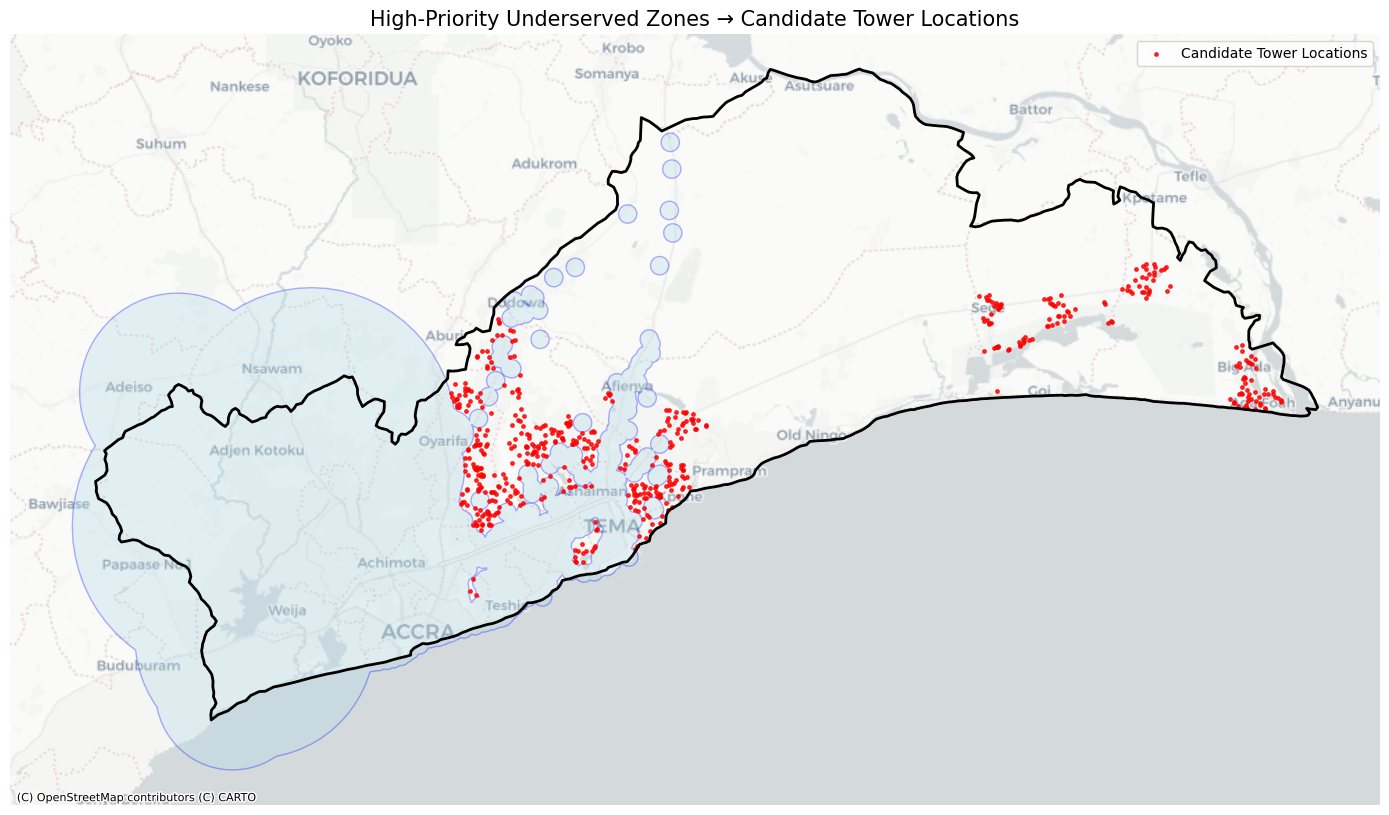

In [34]:
# Visualise high priority zones by Candiddate tower locations

import rasterio
from rasterio.features import geometry_mask
from rasterio.warp import calculate_default_transform, reproject, Resampling
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import contextily as ctx

pop_path = r'I:\GEO DATA ANALYSIS\Telecom_Accra_Optimization\data\processed\greater_accra_population_2020.tif'
TARGET_CRS = 'EPSG:32630'

def reproject_raster(path, target_crs):
    with rasterio.open(path) as src:
        transform, width, height = calculate_default_transform(
            src.crs, target_crs, src.width, src.height, *src.bounds
        )
        data = src.read(1)
        dest = np.zeros((height, width), dtype=data.dtype)
        reproject(
            source=data,
            destination=dest,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=target_crs,
            resampling=Resampling.nearest
        )
        return dest, transform, target_crs 

# Reproject population
pop_data, pop_transform, pop_crs = reproject_raster(pop_path, TARGET_CRS)

# Align coverage to UTM
coverage_dynamic_utm = coverage_dynamic_gdf.to_crs(TARGET_CRS)

# Mask: True = inside coverage
mask_covered = geometry_mask(
    coverage_dynamic_utm.geometry.values,
    out_shape=pop_data.shape,
    transform=pop_transform,
    invert=True
)

# Underserved
underserved = np.where((~mask_covered) & (pop_data > 0), pop_data, 0)

# Top 10% underserved pixels = priority
if underserved.sum() > 0:
    threshold = np.percentile(underserved[underserved > 0], 90)
    priority_mask = underserved >= threshold
else:
    print("No underserved population")
    priority_mask = np.zeros_like(underserved, dtype=bool)

# Convert priority pixels to points
rows, cols = np.where(priority_mask)
xs, ys = rasterio.transform.xy(pop_transform, rows, cols)
priority_points = gpd.GeoDataFrame(
    geometry=[Point(x, y) for x, y in zip(xs, ys)],
    crs=TARGET_CRS
)

print(f"Raw priority points: {len(priority_points)}")

# Cluster / sample to reduce density
priority_sampled = priority_points.sample(frac=0.02, random_state=42)  # 2% sample

# Save
priority_sampled.to_file(
    r'I:\GEO DATA ANALYSIS\Telecom_Accra_Optimization\data\processed\priority_tower_locations.geojson',
    driver='GeoJSON'
)
print("Saved priority locations: priority_tower_locations.geojson")

# Plot
fig, ax = plt.subplots(figsize=(14, 12))

# Reproject for basemap (3857)
priority_web = priority_sampled.to_crs(epsg=3857)
coverage_web = coverage_dynamic_gdf.to_crs(epsg=3857)
boundary_web = gdf_boundary.to_crs(epsg=3857)

coverage_web.plot(ax=ax, color='lightblue', alpha=0.3, edgecolor='blue', zorder=2)
priority_web.plot(ax=ax, color='red', markersize=6, alpha=0.8, label='Candidate Tower Locations', zorder=4)
boundary_web.plot(ax=ax, color='none', edgecolor='black', linewidth=2, zorder=5)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# Add low-opacity population background
with rasterio.open(pop_path) as src_pop:
    pop_web = src_pop.read(1)
    pop_transform_web = src_pop.transform
    

ax.set_title("High-Priority Underserved Zones → Candidate Tower Locations", fontsize=15)
ax.legend()
ax.set_axis_off()
plt.tight_layout()
plt.show()

Coverage created
Raster reprojected to UTM
Total underserved population: 564,832
High-density underserved pixels: 27132
Found 16 clusters
Clusters after filtering (>= 5000 pop): 8
      cluster_pop                       geometry
1    15292.252930   POINT (889915.144 653472.79)
2    13327.525391  POINT (873230.568 648789.178)
3     7953.077637  POINT (879911.012 650232.117)
6   128433.546875  POINT (820509.825 635428.997)
7    23095.486328  POINT (901166.119 642195.887)
11   68916.781250  POINT (836641.594 632556.899)
13   27506.886719  POINT (828552.439 624479.341)
14   15677.416992    POINT (816157.83 619939.94)
Top 20 candidates saved


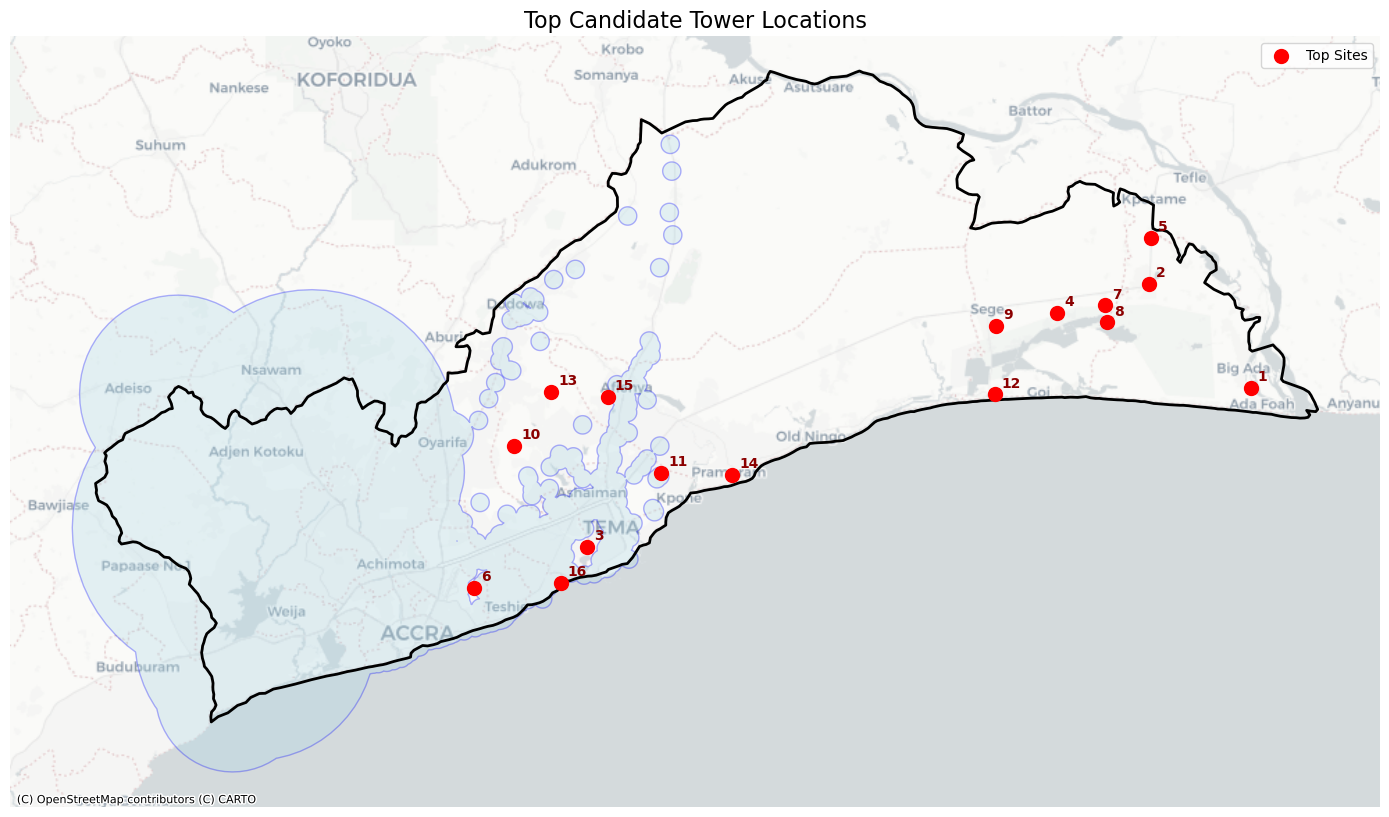

In [35]:
# Apply MCDA and Scoring

import pandas as pd
import geopandas as gpd
import numpy as np
import rasterio
from rasterio.features import geometry_mask
from rasterio.warp import calculate_default_transform, reproject, Resampling
from shapely.geometry import Point
from sklearn.cluster import DBSCAN
from scipy.spatial import KDTree
import matplotlib.pyplot as plt
import contextily as ctx
import os

# Paths
processed_dir = r'I:\GEO DATA ANALYSIS\Telecom_Accra_Optimization\data\processed'
raw_dir      = r'I:\GEO DATA ANALYSIS\Telecom_Accra_Optimization\data\raw'

towers_csv   = os.path.join(processed_dir, 'accra_towers_boundary.csv')
pop_raster   = os.path.join(processed_dir, 'greater_accra_population_2020.tif')
boundary_shp = os.path.join(processed_dir, 'greater_accra_boundary.shp')
roads_shp    = os.path.join(raw_dir, 'greater_accra_roads.shp')

TARGET_CRS   = 'EPSG:32630'  
WEB_CRS      = 'EPSG:3857'  

# Load vector data
df_towers = pd.read_csv(towers_csv)
gdf_towers = gpd.GeoDataFrame(
    df_towers,
    geometry=gpd.points_from_xy(df_towers.lon, df_towers.lat),
    crs="EPSG:4326"
)
gdf_boundary = gpd.read_file(boundary_shp)
roads = gpd.read_file(roads_shp).to_crs(TARGET_CRS)

# Reproject towers & boundary
gdf_towers_utm = gdf_towers.to_crs(TARGET_CRS)
gdf_boundary_utm = gdf_boundary.to_crs(TARGET_CRS)


# Create buffers
gdf_towers_utm['buffer_dynamic'] = gdf_towers_utm.geometry.buffer(
    gdf_towers_utm['range'].clip(100, 20000)
)
coverage_dynamic_gdf = gpd.GeoDataFrame(geometry=[gdf_towers_utm['buffer_dynamic'].union_all()], crs=TARGET_CRS)

print("Coverage created")

# Reproject Population Raster To UTM
with rasterio.open(pop_raster) as src:
    transform, width, height = calculate_default_transform(
        src.crs, TARGET_CRS, src.width, src.height, *src.bounds
    )
    kwargs = src.meta.copy()
    kwargs.update({
        'crs': TARGET_CRS,
        'transform': transform,
        'width': width,
        'height': height
    })

    pop_data = np.empty((height, width), dtype=src.dtypes[0])
    reproject(
        source=rasterio.band(src, 1),
        destination=pop_data,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=transform,
        dst_crs=TARGET_CRS,
        resampling=Resampling.nearest
    )
    pop_transform = transform
    pop_nodata = src.nodata if src.nodata is not None else -99999

print("Raster reprojected to UTM")


# Underserved Population
mask_covered = geometry_mask(
    coverage_dynamic_gdf.geometry.values,
    out_shape=pop_data.shape,
    transform=pop_transform,
    invert=True
)
underserved = np.where((~mask_covered) & (pop_data != pop_nodata) & (pop_data > 0), pop_data, 0)
print(f"Total underserved population: {underserved.sum():,.0f}")

# DBSCAN Clustering 
threshold = np.percentile(underserved[underserved > 0], 90)
high_density_mask = underserved >= threshold
rows, cols = np.where(high_density_mask) 
xs, ys = rasterio.transform.xy(pop_transform, rows, cols)
coords = np.column_stack((xs, ys))

print(f"High-density underserved pixels: {len(coords)}")

if len(coords) < 10:
    print("Too few points — lower threshold or use all underserved.")
else:
    # Tuned DBSCAN
    db = DBSCAN(eps=1000, min_samples=20, metric='euclidean', n_jobs=-1).fit(coords)
    labels = db.labels_

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"Found {n_clusters} clusters")

    cluster_points = []
    cluster_pop = []
    for label in set(labels):
        if label == -1:
            continue
            
        # Get indices of pixels in this cluster
        cluster_idx = np.where(labels == label)[0]
        
        # Sum population from those exact pixels
        cluster_pop_sum = underserved[rows[cluster_idx], cols[cluster_idx]].sum()
        cluster_pop.append(cluster_pop_sum)

        # Centroid
        cluster_coords = coords[cluster_idx]
        centroid_x, centroid_y = cluster_coords.mean(axis=0)
        cluster_points.append(Point(centroid_x, centroid_y))

    candidates = gpd.GeoDataFrame(
        {'cluster_pop': cluster_pop},
        geometry=cluster_points,
        crs=TARGET_CRS
    )

    # Filter clusters by minimum population
    min_pop_threshold = 5000
    candidates_filtered = candidates[candidates['cluster_pop'] >= min_pop_threshold]

    print(f"Clusters after filtering (>= {min_pop_threshold} pop): {len(candidates_filtered)}")
    print(candidates_filtered[['cluster_pop', 'geometry']])

    # Save
    candidates_filtered.to_file(
        os.path.join(processed_dir, 'filtered_cluster_candidates.geojson'),
        driver='GeoJSON'
    )

# Scoring
tower_coords = np.array(list(zip(gdf_towers_utm.geometry.x, gdf_towers_utm.geometry.y)))
tower_tree = KDTree(tower_coords)

road_coords = np.array(list(zip(roads.centroid.x, roads.centroid.y)))
road_tree = KDTree(road_coords)

candidates['pop_served'] = 0.0
candidates['dist_to_tower'] = 0.0
candidates['dist_to_road'] = 0.0

for i, row in candidates.iterrows():
    pt = row.geometry
    buffer = pt.buffer(2500)
    pop = underserved[geometry_mask([buffer], out_shape=pop_data.shape, transform=pop_transform, invert=True)].sum()
    d_tower, _ = tower_tree.query([pt.x, pt.y])
    d_road, _ = road_tree.query([pt.x, pt.y])
    candidates.loc[i, ['pop_served','dist_to_tower','dist_to_road']] = [pop, d_tower, d_road]

candidates['score'] = (
    (candidates['pop_served']/candidates['pop_served'].max())*0.5 +
    (candidates['dist_to_tower']/candidates['dist_to_tower'].max())*0.3 -
    (candidates['dist_to_road']/candidates['dist_to_road'].max())*0.2
)

top_candidates = candidates.sort_values('score', ascending=False).head(20)
top_candidates.to_file(os.path.join(processed_dir,'top_candidates.geojson'), driver='GeoJSON')
print("Top 20 candidates saved")

# Visualization with Web Mercator
top_web = top_candidates.to_crs(WEB_CRS)
coverage_web = coverage_dynamic_gdf.to_crs(WEB_CRS)
boundary_web = gdf_boundary.to_crs(WEB_CRS)

fig, ax = plt.subplots(figsize=(14,12))
coverage_web.plot(ax=ax, color='lightblue', alpha=0.3, edgecolor='blue')
boundary_web.plot(ax=ax, color='none', edgecolor='black', linewidth=2)
top_web.plot(ax=ax, color='red', markersize=100, label='Top Sites')

# Add ranking
for rank, (_, row) in enumerate(top_web.iterrows(), start=1):
    ax.annotate(
        str(rank),
        xy=(row.geometry.x,row.geometry.y),
        xytext=(5,5),
        textcoords="offset points",
        fontsize=10,
        color='darkred',
        weight='bold'
    )

ctx.add_basemap(ax, crs=WEB_CRS, source=ctx.providers.CartoDB.Positron)
ax.set_title("Top Candidate Tower Locations", fontsize=16)
ax.legend()
ax.set_axis_off()
plt.tight_layout()
plt.savefig(os.path.join(processed_dir,'final_map.png'), dpi=300)
plt.show()

In [36]:
# Add more Variables

# Load DEM
dem_path = os.path.join(raw_dir, 'greater_accra_dem.tif')

with rasterio.open(dem_path) as src_dem:
    dem_data = src_dem.read(1)
    dem_transform = src_dem.transform
    dem_crs = src_dem.crs

    # Reproject DEM to TARGET_CRS if not already
    if dem_crs != TARGET_CRS:
        transform_dem, width_dem, height_dem = calculate_default_transform(
            dem_crs, TARGET_CRS, src_dem.width, src_dem.height, *src_dem.bounds
        )
        dem_utm = np.empty((height_dem, width_dem), dtype=dem_data.dtype)
        reproject(
            source=dem_data,
            destination=dem_utm,
            src_transform=dem_transform,
            src_crs=dem_crs,
            dst_transform=transform_dem,
            dst_crs=TARGET_CRS,
            resampling=Resampling.bilinear
        )
        dem_data = dem_utm
        dem_transform = transform_dem

    # Calculate slope (degrees) using simple finite difference
    from rasterio import features
    
    # Simple numpy slope approximation
    dy, dx = np.gradient(dem_data, 30)  # 30 m resolution
    slope = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))
    slope[np.isnan(slope)] = 0

# Add slope penalty to candidates
candidates['avg_slope_deg'] = 0.0

for idx, row in candidates.iterrows():
    pt = row.geometry
    buffer_1000 = pt.buffer(1000)  # average slope in 1 km radius
    slope_in_buffer = slope[
        geometry_mask([buffer_1000], out_shape=slope.shape, transform=dem_transform, invert=True)
    ]
    avg_slope = slope_in_buffer.mean() if len(slope_in_buffer) > 0 else 0
    candidates.at[idx, 'avg_slope_deg'] = avg_slope

# Update score: penalize steep slopes (>10°)
candidates['slope_penalty'] = np.where(candidates['avg_slope_deg'] > 10, 0.7, 1.0)  # 30% penalty if steep

candidates['score'] = (
    (candidates['pop_served'] / candidates['pop_served'].max()) * 0.5 +
    (candidates['dist_to_tower'] / candidates['dist_to_tower'].max()) * 0.25 +
    (candidates['dist_to_road'] / candidates['dist_to_road'].max()) * 0.15 -
    (candidates['avg_slope_deg'] / 30) * 0.1  # extra slope penalty
) * candidates['slope_penalty']

top_candidates = candidates.sort_values('score', ascending=False).head(20)

print("Top 20 after adding slope constraint:")
print(top_candidates[['pop_served', 'dist_to_tower', 'dist_to_road', 'avg_slope_deg', 'score']])

Top 20 after adding slope constraint:
      pop_served  dist_to_tower  dist_to_road  avg_slope_deg     score
13  25476.574219    1920.035094    461.017368       2.637423  0.601163
1   16286.261719   52399.956764     16.838683       2.546299  0.516253
2   11457.792969   36771.142013    674.160200       2.842982  0.506696
3   12044.503906   42952.881386    269.420226       3.082501  0.451113
4    7715.895996   47963.593470    348.931018       2.936448  0.403594
7   17358.556641   65056.946113    131.962652      13.208970  0.403206
5    6585.354492   48529.518095    372.205151       3.525462  0.386796
0    5276.040039   52348.096111    147.459179       5.335005  0.319736
14  15677.416992     926.446863     56.713841       2.682534  0.314920
11  12688.773438     412.430541    241.944554       1.934600  0.297997
6   11956.867188    3625.529602    196.613850       2.604707  0.283660
10   3128.180664   37106.487145    213.684821       6.346156  0.230376
8    6596.232422    4888.826821     98.

In [ ]:
# Load and Clip Land Cover
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import os

processed_dir = r'I:\GEO DATA ANALYSIS\Telecom_Accra_Optimization\data\processed'
raw_dir      = r'I:\GEO DATA ANALYSIS\Telecom_Accra_Optimization\data\raw'

merged_path = os.path.join(processed_dir, 'esa_worldcover_merged_greater_accra.tif')
boundary_path = os.path.join(processed_dir, 'greater_accra_boundary.shp')
clipped_path = os.path.join(processed_dir, 'esa_worldcover_clipped.tif')

with rasterio.open(merged_path) as src:
    gdf_boundary = gpd.read_file(boundary_path)
    geoms = [feature["geometry"] for feature in gdf_boundary.__geo_interface__["features"]]

    out_image, out_transform = mask(src, geoms, crop=True, nodata=0)
    out_meta = src.meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform,
        "nodata": 0
    })

    with rasterio.open(clipped_path, "w", **out_meta) as dest:
        dest.write(out_image)

print(f"Clipped land cover saved: {clipped_path}")

Land cover clipped raster reprojected to UTM 32630
Unique classes: [ 0 10 20 30 40 50 60 80 90 95]
Top 20 after FULL MCDA (pop + tower dist + roads + slope + land use):
      pop_served  dist_to_tower  dist_to_road  avg_slope_deg  unsuitable_frac  \
1   16286.261719   52399.956764     16.838683       2.546299         0.026289   
2   11457.792969   36771.142013    674.160200       2.842982         0.202068   
13  25476.574219    1920.035094    461.017368       2.637423         0.270900   
3   12044.503906   42952.881386    269.420226       3.082501         0.193948   
5    6585.354492   48529.518095    372.205151       3.525462         0.162399   
4    7715.895996   47963.593470    348.931018       2.936448         0.193778   
0    5276.040039   52348.096111    147.459179       5.335005         0.191313   
14  15677.416992     926.446863     56.713841       2.682534         0.166917   
11  12688.773438     412.430541    241.944554       1.934600         0.197890   
7   17358.556641   65

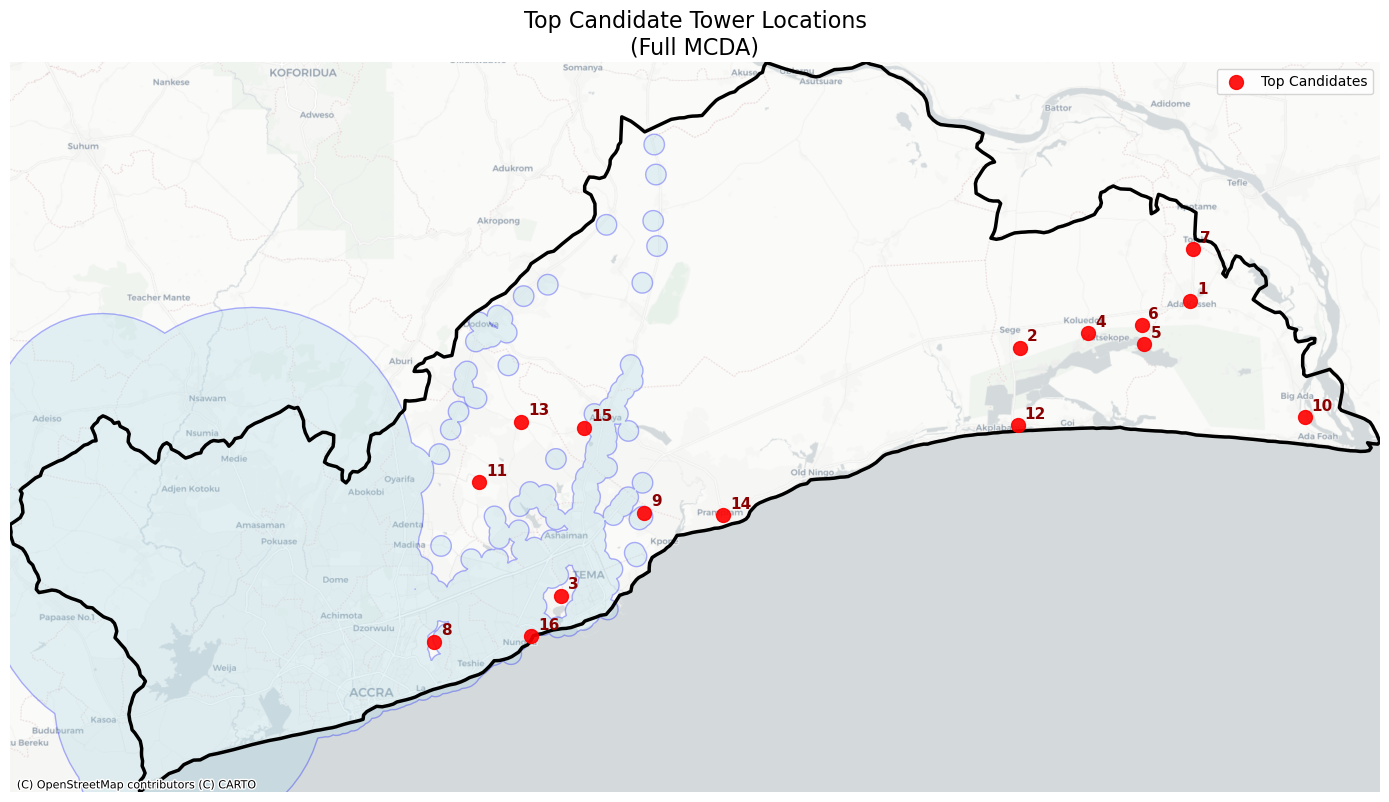

In [38]:
# Add clipped Land Cover and Apply MCDA
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.features import geometry_mask
import numpy as np
import geopandas as gpd
import os


# Load clipped WorldCover & reproject to UTM 32630
lc_clipped_path = r'I:\GEO DATA ANALYSIS\Telecom_Accra_Optimization\data\processed\esa_worldcover_clipped.tif'

with rasterio.open(lc_clipped_path) as src_lc:
    lc_data = src_lc.read(1)
    lc_transform = src_lc.transform
    lc_crs = src_lc.crs

    if lc_crs != TARGET_CRS:
        transform_lc, width_lc, height_lc = calculate_default_transform(
            lc_crs, TARGET_CRS, src_lc.width, src_lc.height, *src_lc.bounds
        )
        lc_utm = np.empty((height_lc, width_lc), dtype=lc_data.dtype)
        reproject(
            source=lc_data,
            destination=lc_utm,
            src_transform=lc_transform,
            src_crs=lc_crs,
            dst_transform=transform_lc,
            dst_crs=TARGET_CRS,
            resampling=Resampling.nearest
        )
        lc_data = lc_utm
        lc_transform = transform_lc
        print("Land cover clipped raster reprojected to UTM 32630")
    else:
        print("Land cover already in UTM 32630")

    print("Unique classes:", np.unique(lc_data))


# Land use penalty
unsuitable_high = [0, 70, 80, 95]   # no data, water, wetland
unsuitable_med  = [20, 90]          # forest, moss/lichen
unsuitable_low  = [10, 30, 40, 60]  # cropland, grass, shrub, bare

candidates['landuse_penalty'] = 1.0
candidates['unsuitable_frac'] = 0.0

for idx, row in candidates.iterrows():
    pt = row.geometry
    buffer_500 = pt.buffer(500)

    lc_in_buffer = lc_data[
        geometry_mask([buffer_500], out_shape=lc_data.shape, transform=lc_transform, invert=True)
    ]

    total_valid = len(lc_in_buffer[lc_in_buffer != 0])
    if total_valid == 0:
        penalty = 0.5
    else:
        high_frac = np.isin(lc_in_buffer, unsuitable_high).sum() / total_valid
        med_frac  = np.isin(lc_in_buffer, unsuitable_med).sum()  / total_valid
        low_frac  = np.isin(lc_in_buffer, unsuitable_low).sum()  / total_valid

        penalty = 1.0 - (high_frac * 1.0 + med_frac * 0.7 + low_frac * 0.2)
        penalty = max(0.1, penalty)  # min 10%

    candidates.at[idx, 'landuse_penalty'] = penalty
    candidates.at[idx, 'unsuitable_frac'] = 1 - penalty


# Final score for all criteria
candidates['score_final'] = (
    (candidates['pop_served'] / candidates['pop_served'].max()) * 0.4 +
    (candidates['dist_to_tower'] / candidates['dist_to_tower'].max()) * 0.25 +
    (candidates['dist_to_road'] / candidates['dist_to_road'].max()) * 0.15 -
    (candidates['avg_slope_deg'] / 30) * 0.1
) * candidates['slope_penalty'] * candidates['landuse_penalty']

# Rank & display top 20
top_candidates_final = candidates.sort_values('score_final', ascending=False).head(20)

print("Top 20 after FULL MCDA (pop + tower dist + roads + slope + land use):")
print(top_candidates_final[['pop_served', 'dist_to_tower', 'dist_to_road', 'avg_slope_deg', 'unsuitable_frac', 'landuse_penalty', 'score_final']])

# Save final
top_candidates_final.to_file(
    os.path.join(processed_dir, 'top_tower_candidates_full_mcda.geojson'),
    driver='GeoJSON'
)
print("Final ranked candidates saved")



# Final Visualization
top_web = top_candidates_final.to_crs(WEB_CRS)
coverage_web = coverage_dynamic_gdf.to_crs(WEB_CRS)
boundary_web = gdf_boundary.to_crs(WEB_CRS)

# Debug check
print("Top candidates count:", len(top_web))
print("Bounds:", top_web.total_bounds)

fig, ax = plt.subplots(figsize=(14, 12))

# Plot layers first so extent is defined
coverage_web.plot(ax=ax, color='lightblue', alpha=0.3, edgecolor='blue', zorder=2)
boundary_web.plot(ax=ax, color='none', edgecolor='black', linewidth=2.5, zorder=3)
top_web.plot(ax=ax, color='red', markersize=100, alpha=0.9, label='Top Candidates', zorder=5)

# Set extent manually
xmin, ymin, xmax, ymax = boundary_web.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# Add basemap after extent is set
ctx.add_basemap(
    ax,
    crs=WEB_CRS,
    source=ctx.providers.CartoDB.Positron,
    zoom=11
)

# Labels
for rank, (_, row) in enumerate(top_web.iterrows(), start=1):
    ax.annotate(
        str(rank),
        xy=(row.geometry.x, row.geometry.y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=11,
        color='darkred',
        weight='bold',
        zorder=6
    )

ax.set_title("Top Candidate Tower Locations\n(Full MCDA)", fontsize=16)
ax.legend(loc='upper right')
ax.set_axis_off()

plt.tight_layout()

# Save
plt.savefig(os.path.join(processed_dir, 'final_mcda_map.png'), dpi=300)

plt.show()

In [49]:
# Add Interactive Folium Map

import folium
import geopandas as gpd
import os
from branca.element import MacroElement
from jinja2 import Template


# Paths
processed_dir = r'I:\GEO DATA ANALYSIS\Telecom_Accra_Optimization\data\processed'

candidates_path = os.path.join(processed_dir, 'top_tower_candidates_full_mcda.geojson')
boundary_path   = os.path.join(processed_dir, 'greater_accra_boundary.shp')
coverage_path   = os.path.join(processed_dir, 'coverage_dynamic_gdf.geojson')


# Load data
top_candidates = gpd.read_file(candidates_path)
gdf_boundary   = gpd.read_file(boundary_path)
coverage_dyn   = gpd.read_file(coverage_path)

# Convert to WGS84 (Folium requirement)
top_candidates = top_candidates.to_crs(epsg=4326)
gdf_boundary   = gdf_boundary.to_crs(epsg=4326)
coverage_dyn   = coverage_dyn.to_crs(epsg=4326)


# Sort by Score
top_candidates = top_candidates.sort_values('score_final', ascending=False).reset_index(drop=True)


# Create Map
m = folium.Map(
    location=[5.6037, -0.1870],  # Accra center
    zoom_start=11,
    tiles='cartodbpositron'
)


# Add boundary
folium.GeoJson(
    gdf_boundary,
    name='Greater Accra Boundary',
    style_function=lambda f: {
        'fillOpacity': 0,
        'color': 'black',
        'weight': 2
    }
).add_to(m)


# Add Coverage
folium.GeoJson(
    coverage_dyn,
    name='Dynamic Coverage',
    style_function=lambda f: {
        'fillColor': 'blue',
        'color': 'blue',
        'fillOpacity': 0.25,
        'weight': 1
    }
).add_to(m)


# Add Candiddates
for idx, row in top_candidates.iterrows():

    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=5,
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.6,
        popup=folium.Popup(
            f"""
            <b>Rank:</b> {idx+1}<br>
            <b>Score:</b> {row['score_final']:.3f}<br>
            <b>Pop Served:</b> {row['pop_served']:.0f}<br>
            <b>Dist to Tower:</b> {row['dist_to_tower']:.0f} m<br>
            <b>Dist to Road:</b> {row['dist_to_road']:.0f} m<br>
            <b>Slope:</b> {row['avg_slope_deg']:.1f}°<br>
            <b>Unsuitable:</b> {row['unsuitable_frac']:.1%}
            """,
            max_width=300
        )
    ).add_to(m)


# Highlight Top 10

for rank, (_, row) in enumerate(top_candidates.head(10).iterrows(), start=1):

    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        popup=f"<b>TOP {rank}</b><br>Score: {row['score_final']:.3f}",
        icon=folium.Icon(color='red', icon='star', prefix='fa')
    ).add_to(m)


# Auto Zoom To Data
bounds = gdf_boundary.total_bounds  # [xmin, ymin, xmax, ymax]
m.fit_bounds([
    [bounds[1], bounds[0]],  # SW
    [bounds[3], bounds[2]]   # NE
])


# Layer Control
folium.LayerControl().add_to(m)


# Save
legend_html = """
{% macro html(this, kwargs) %}

<div style="
    position: fixed;
    bottom: 40px;
    left: 40px;
    width: 260px;
    height: auto;
    z-index:9999;
    font-size:14px;
    background-color: white;
    border:2px solid grey;
    border-radius:8px;
    padding: 10px;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
">
<b>Legend</b><br><br>

<i style="background:blue;opacity:0.4;width:15px;height:15px;display:inline-block;"></i>
&nbsp; Dynamic Coverage<br><br>

<i style="background:red;width:10px;height:10px;border-radius:50%;display:inline-block;"></i>
&nbsp; Candidate Locations<br><br>

<i class="fa fa-star" style="color:red"></i>
&nbsp; Top 10 Candidates<br><br>

<i style="border:2px solid black;width:15px;height:15px;display:inline-block;"></i>
&nbsp; Region Boundary

</div>

{% endmacro %}
"""

legend = MacroElement()
legend._template = Template(legend_html)

m.get_root().add_child(legend)
html_path = os.path.join(processed_dir, 'top_candidates_interactive_full.html')
m.save(html_path)

print(f" Interactive map saved: {html_path}")

 Interactive map saved: I:\GEO DATA ANALYSIS\Telecom_Accra_Optimization\data\processed\top_candidates_interactive_full.html


In [2]:
# Process csv for Power BI

import geopandas as gpd
import os

processed_dir = r'I:\GEO DATA ANALYSIS\Telecom_Accra_Optimization\data\processed'

# Load final candidates (in UTM)
gdf = gpd.read_file(os.path.join(processed_dir, 'top_tower_candidates_full_mcda.geojson'))

# Reproject to WGS84 (4326)
gdf_4326 = gdf.to_crs(epsg=4326)

# Extract clean lat/lon columns
gdf_4326['latitude']  = gdf_4326.geometry.y
gdf_4326['longitude'] = gdf_4326.geometry.x

# Add rank column
gdf_4326 = gdf_4326.sort_values('score_final', ascending=False).reset_index(drop=True)
gdf_4326['rank'] = gdf_4326.index + 1

# Drop geometry column
gdf_4326 = gdf_4326.drop(columns='geometry')

# Save
csv_path = os.path.join(processed_dir, 'top_candidates_powerbi_final.csv')
gdf_4326.to_csv(csv_path, index=False)

print(f"Clean Power BI CSV saved: {csv_path}")
print("Columns now include: rank, latitude, longitude, pop_served, dist_to_tower, dist_to_road, avg_slope_deg, unsuitable_frac, landuse_penalty, score_final")

Clean Power BI CSV saved: I:\GEO DATA ANALYSIS\Telecom_Accra_Optimization\data\processed\top_candidates_powerbi_final.csv
Columns now include: rank, latitude, longitude, pop_served, dist_to_tower, dist_to_road, avg_slope_deg, unsuitable_frac, landuse_penalty, score_final
